# Notebook 6 — Model comparison (LSTM vs baselines)

## 1. Introduction

**Purpose.** This notebook compares the pharmacy **LSTM** forecaster (multivariate sequence model used in production) against two common baselines: **linear regression** and **random forest regression** on the **same** monthly demand series, **same** train/test split, and **same** metrics (MAE, RMSE, MAPE).

**Why compare models?** Deep learning can capture non-linear patterns, but simpler models are easier to interpret, train faster, and may generalize well when data are limited. Reporting multiple approaches shows awareness of alternatives and supports an evidence-based choice of forecaster.

**Setup (aligned with the project pipeline).**
- **Data:** `outputs/monthly_demand.csv` (and `data/stock_receipts.csv` only to rebuild LSTM input features consistently with the app).
- **Split:** **Time-based** — training on all months **except** the last **3** calendar months; **test** on those last 3 months (walk-forward targets).
- **Tabular models (Linear / RF):** 12 lagged monthly demands → predict next month (12 → 1 supervised learning problem).
- **LSTM:** Uses the **saved** checkpoint (`models/lstm_model.h5`) and scaler; **one-step** prediction for each test month from the preceding 12 months (aligned with the 12-lag design).  
  `outputs/next_3_month_forecast.csv` is **not** used here: it targets months **after** the end of the history, so it does not share the same `y_true` as this holdout.  
  *Note:* The saved LSTM was trained in the full pipeline on the **entire** series. Linear and RF are trained **only** on training-month rows, so their test scores are a stricter out-of-sample benchmark. The LSTM row reflects **production-style** weights; see the conclusion.

## 2. Environment and imports

In [2]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from app.monthly_lstm_features import LSTM_FEATURE_COLUMNS, enrich_monthly_with_lstm_features
from app.paths import MODELS_DIR, OUTPUTS_DIR
from app.utils import mape as mape_fn
from app.forecasting import _load_scaler, _inverse_first_feature

warnings.filterwarnings("ignore", category=UserWarning)

MONTHLY_PATH = OUTPUTS_DIR / "monthly_demand.csv"
STOCK_PATH = ROOT / "data" / "stock_receipts.csv"
MODEL_H5 = MODELS_DIR / "lstm_model.h5"
SCALER_PATH = MODELS_DIR / "lstm_scaler.npy"

N_LAGS = 12
N_TEST_MONTHS = 3
RNG = 42

## 3. Load and sort data

Load `monthly_demand.csv`, parse `month`, and sort by `drug_id`, `month`.

In [3]:
monthly = pd.read_csv(MONTHLY_PATH)
monthly["month"] = pd.to_datetime(monthly["month"])
monthly["drug_id"] = monthly["drug_id"].astype(str)
monthly = monthly.sort_values(["drug_id", "month"]).reset_index(drop=True)

assert "monthly_demand" in monthly.columns
monthly.head()

,drug_id,month,monthly_demand
0,D001,2019-01-01,2478
1,D001,2019-02-01,2692
2,D001,2019-03-01,3052
3,D001,2019-04-01,2941
4,D001,2019-05-01,3075


## 4. Train / test split (time-based)

- **Test:** the **last 3** distinct calendar months in the dataset.  
- **Train (for tabular models):** all **earlier** months (targets only before the first test month).

This avoids lookahead: we never train tabular models on rows whose target falls in the test window.

In [4]:
all_months = np.sort(monthly["month"].unique())
test_months = all_months[-N_TEST_MONTHS:]
first_test = pd.Timestamp(test_months[0])

print("Date range:", monthly["month"].min(), "→", monthly["month"].max())
print("Test months (holdout):", [pd.Timestamp(m).strftime("%Y-%m") for m in test_months])

Date range: 2019-01-01 00:00:00 → 2024-12-01 00:00:00
Test months (holdout): ['2024-10', '2024-11', '2024-12']


## 5. Supervised table (12 lags → next month)

For each `drug_id`, for each index \(i \ge 12\), features = demands at \(i-12,\ldots,i-1\), target = demand at \(i\).  
Rows are labeled with the **target month** for splitting.

In [5]:
def build_supervised_lags(df: pd.DataFrame, n_lags: int = 12) -> pd.DataFrame:
    rows = []
    for did, g in df.groupby("drug_id", sort=False):
        g = g.sort_values("month")
        vals = g["monthly_demand"].to_numpy(dtype=float)
        mts = g["month"].to_numpy()
        for i in range(n_lags, len(g)):
            row = {f"lag_{k + 1}": vals[i - n_lags + k] for k in range(n_lags)}
            row["drug_id"] = did
            row["target_month"] = pd.Timestamp(mts[i])
            row["y"] = float(vals[i])
            rows.append(row)
    return pd.DataFrame(rows)


sup = build_supervised_lags(monthly, N_LAGS)
lag_cols = [f"lag_{k}" for k in range(1, N_LAGS + 1)]

train_mask = sup["target_month"] < first_test
test_mask = sup["target_month"].isin(test_months)

X_train = sup.loc[train_mask, lag_cols].to_numpy()
y_train = sup.loc[train_mask, "y"].to_numpy()
X_test = sup.loc[test_mask, lag_cols].to_numpy()
y_test = sup.loc[test_mask, "y"].to_numpy()

print("Supervised rows — train:", train_mask.sum(), " test:", test_mask.sum())
sup.loc[test_mask, ["drug_id", "target_month", "y"]].head()

Supervised rows — train: 1995  test: 105


,drug_id,target_month,y
57,D001,2024-10-01,3515.0
58,D001,2024-11-01,3437.0
59,D001,2024-12-01,3321.0
117,D002,2024-10-01,1574.0
118,D002,2024-11-01,1545.0


## 6. Model 1 — Linear regression

In [6]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)
pred_lin = np.clip(pred_lin, 0, None)

## 7. Model 2 — Random Forest

Reasonable defaults: `n_estimators=200`, `max_depth=None`, `random_state` fixed for reproducibility.

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=RNG,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
pred_rf = np.clip(pred_rf, 0, None)

## 8. Model 3 — LSTM (saved pipeline)

Rebuild multivariate monthly features (same as the app), load `lstm_model.h5` and the **MinMaxScaler**, then for each **test** supervised row predict one step from the 12 preceding months.

*If TensorFlow is unavailable or files are missing, this cell sets LSTM predictions to NaN and metrics are reported only for baselines.*

In [8]:
test_rows = sup.loc[test_mask].reset_index(drop=True)
pred_lstm = np.full(len(test_rows), np.nan, dtype=float)

try:
    from tensorflow.keras.models import load_model

    stock = pd.read_csv(STOCK_PATH) if STOCK_PATH.exists() else pd.DataFrame()
    monthly_enriched = enrich_monthly_with_lstm_features(monthly.copy(), stock)
    scaler_lstm = _load_scaler(SCALER_PATH)

    try:
        lstm = load_model(MODEL_H5, compile=False)
    except Exception:
        lstm = load_model(MODEL_H5, compile=False, safe_mode=False)

    lstm.compile(optimizer="adam", loss="mse")
    n_feat = int(lstm.input_shape[-1])
    seq_len = int(lstm.input_shape[1])

    for j, row in test_rows.iterrows():
        did = row["drug_id"]
        tm = pd.Timestamp(row["target_month"])
        sub = monthly_enriched[monthly_enriched["drug_id"] == did].sort_values("month")
        past = sub[sub["month"] < tm]
        if len(past) < seq_len:
            continue
        win = past.tail(seq_len)
        if n_feat == 1:
            v = win["monthly_demand"].astype(float).values.reshape(-1, 1)
            Xs = scaler_lstm.transform(v)
        else:
            Xs = scaler_lstm.transform(win[LSTM_FEATURE_COLUMNS].astype(float).values)
        if Xs.shape[1] != n_feat:
            continue
        p_scaled = float(lstm.predict(Xs.reshape(1, seq_len, n_feat), verbose=0)[0, 0])
        p = float(_inverse_first_feature(scaler_lstm, np.array([p_scaled]))[0])
        pred_lstm[j] = max(0.0, p)

except Exception as e:
    print("LSTM inference skipped:", e)

## 9. Evaluation metrics

Same definitions for all models: **MAE**, **RMSE**, **MAPE** (using `app.utils.mape`, which ignores zero denominators in the usual way).

In [9]:
def metrics_report(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mask = np.isfinite(y_pred)
    if mask.sum() == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan}
    yt = y_true[mask]
    yp = y_pred[mask]
    return {
        "MAE": float(mean_absolute_error(yt, yp)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAPE": float(mape_fn(yt, yp)),
    }


rows = [
    {"Model": "Linear regression", **metrics_report(y_test, pred_lin)},
    {"Model": "Random forest", **metrics_report(y_test, pred_rf)},
    {"Model": "LSTM (saved checkpoint)", **metrics_report(y_test, pred_lstm)},
]

results = pd.DataFrame(rows)
results

,Model,MAE,RMSE,MAPE
0,Linear regression,25.486745,43.457163,1.752153
1,Random forest,29.262476,49.428763,1.951580
2,LSTM (saved checkpoint),45.582974,62.601790,3.208077


## 10. Results table (formatted)

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| … | … | … | … |

(Values appear in the DataFrame above; round for reporting.)

In [10]:
display_df = results.copy()
for c in ["MAE", "RMSE", "MAPE"]:
    display_df[c] = display_df[c].map(lambda x: round(x, 3) if pd.notna(x) else "—")
display_df

,Model,MAE,RMSE,MAPE
0,Linear regression,25.487,43.457,1.752
1,Random forest,29.262,49.429,1.952
2,LSTM (saved checkpoint),45.583,62.602,3.208


## 11. Visualization

Scatter: actual vs predicted on the **test** set (one point per drug–month).  
Optionally compare error distributions across models.

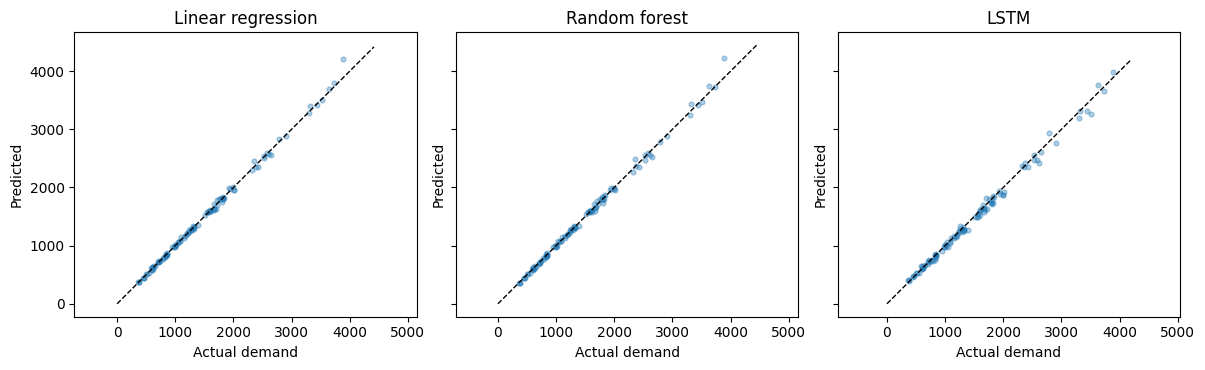

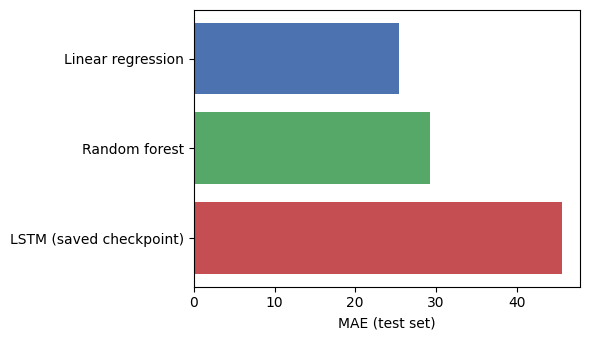

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
models_plot = [
    ("Linear regression", pred_lin),
    ("Random forest", pred_rf),
    ("LSTM", pred_lstm),
]
for ax, (name, pred) in zip(axes, models_plot):
    m = np.isfinite(pred)
    ax.scatter(y_test[m], pred[m], alpha=0.35, s=12)
    lim = [0, max(y_test.max(), np.nanmax(pred)) * 1.05]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("Actual demand")
    ax.set_ylabel("Predicted")
    ax.set_title(name)
    ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

# Bar chart of MAE by model
fig2, ax2 = plt.subplots(figsize=(6, 3.5))
ok = results.dropna(subset=["MAE"])
ax2.barh(ok["Model"], ok["MAE"], color=["#4C72B0", "#55A868", "#C44E52"][: len(ok)])
ax2.set_xlabel("MAE (test set)")
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

## 12. Conclusion

**Which model performed best?**  
Compare **MAE / RMSE / MAPE** on the table above on the **same** last-three-month test window. Lower error is better (subject to MAPE caveats when demand is near zero).

**Why might one model win?**  
- **Linear regression** assumes a linear relationship between lags and the next value — strong when the series is smooth and trends are stable.  
- **Random forest** can capture non-linear interactions between lags without hand-crafted features.  
- **LSTM** models sequential structure and (in this project) **seasonality and expiry-related** inputs; it may track complex patterns but is heavier to train and depends on the quality of the saved checkpoint.

**Trade-offs.**  
- **Interpretability:** linear > forest (partial) > LSTM.  
- **Training cost:** linear < forest < LSTM.  
- **Fairness of this comparison:** tabular models were trained **only** on pre-test targets; the **LSTM** artifact was produced by the **full** pipeline (trained on the complete history). For a strictly like-for-like study, you would retrain the LSTM **only** on training months — at the cost of longer runtime and tuning.

**Takeaway.** Use this notebook to **justify** keeping the LSTM if it clearly wins on out-of-sample error **or** to justify simpler models if baselines are competitive with lower operational complexity.